In [15]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
np.random.seed(42)

In [16]:
# Generate some random data for linear regression
# y = 2x + 3 + noise
true_weight = 2.0
true_bias = 3.0
x = np.linspace(-1,1,200).astype(np.float32).reshape(-1,1)
y = true_weight*x + true_bias + np.random.normal(0, 0.1, size=x.shape).astype(np.float32)

print(f"x shape: {x.shape}, x dtype: {x.dtype}")
print(f"y shape: {y.shape}, y dtype: {y.dtype}")

x shape: (200, 1), x dtype: float32
y shape: (200, 1), y dtype: float32


In [17]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}, X_train dtype: {X_train.dtype}")
print(f"X_test shape: {X_test.shape}, X_test dtype: {X_test.dtype}")
print(f"y_train shape: {y_train.shape}, y_train dtype: {y_train.dtype}")
print(f"y_test shape: {y_test.shape}, y_test dtype: {y_test.dtype}")

X_train shape: (160, 1), X_train dtype: float32
X_test shape: (40, 1), X_test dtype: float32
y_train shape: (160, 1), y_train dtype: float32
y_test shape: (40, 1), y_test dtype: float32


In [18]:
# Converting numpy arrays to torch tensors
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)   
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test)

print(f"X_train_t shape: {X_train_t.shape}, X_train_t dtype: {X_train_t.dtype}")
print(f"y_train_t shape: {y_train_t.shape}, y_train_t dtype: {y_train_t.dtype}")
print(f"X_test_t shape: {X_test_t.shape}, X_test_t dtype: {X_test_t.dtype}")
print(f"y_test_t shape: {y_test_t.shape}, y_test_t dtype: {y_test_t.dtype}")

X_train_t shape: torch.Size([160, 1]), X_train_t dtype: torch.float32
y_train_t shape: torch.Size([160, 1]), y_train_t dtype: torch.float32
X_test_t shape: torch.Size([40, 1]), X_test_t dtype: torch.float32
y_test_t shape: torch.Size([40, 1]), y_test_t dtype: torch.float32


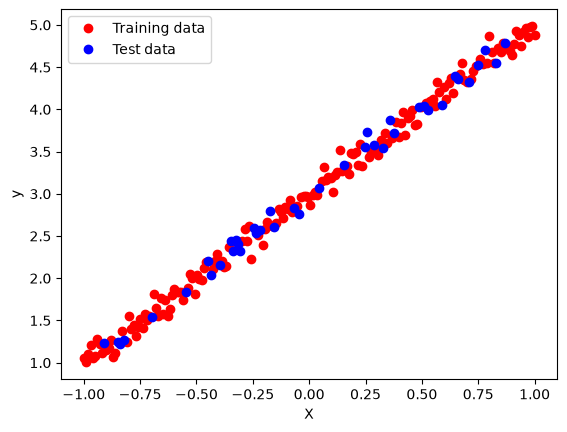

In [19]:
plt.plot(X_train, y_train, 'ro', label='Training data')
plt.plot(X_test, y_test, 'bo', label='Test data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [20]:
# Training using simple linear regression model in PyTorch

model = nn.Linear(1, 1)  # Linear regression model with 1 input and 1 output
loss_function = nn.MSELoss()  # Mean Squared Error loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # Stochastic Gradient Descent optimizer

n_epochs = 1000
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()  # Zero the gradients
    y_pred = model(X_train_t)  # Forward pass
    loss = loss_function(y_pred, y_train_t)  # Compute the loss
    loss.backward()  # Backward pass
    optimizer.step()  # Update the weights

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}')


Epoch [100/1000], Loss: 0.9342
Epoch [200/1000], Loss: 0.1817
Epoch [300/1000], Loss: 0.0497
Epoch [400/1000], Loss: 0.0187
Epoch [500/1000], Loss: 0.0112
Epoch [600/1000], Loss: 0.0094
Epoch [700/1000], Loss: 0.0089
Epoch [800/1000], Loss: 0.0088
Epoch [900/1000], Loss: 0.0088
Epoch [1000/1000], Loss: 0.0088


In [21]:
# Check model parameters
weight = model.weight.item()
bias = model.bias.item()
print(f"True weight: {true_weight}, True bias: {true_bias}")
print(f"Learned weight: {weight:.4f}, Learned bias: {bias:.4f}")

True weight: 2.0, True bias: 3.0
Learned weight: 2.0061, Learned bias: 2.9937


Test Loss: 0.0077


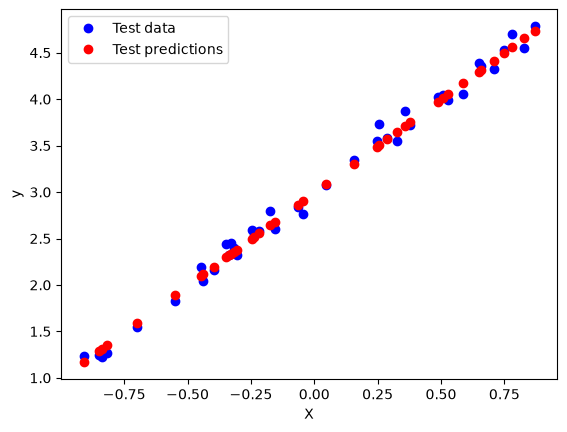

In [22]:
with torch.no_grad():
    y_test_pred = model(X_test_t)
    test_loss = loss_function(y_test_pred, y_test_t)
    print(f'Test Loss: {test_loss.item():.4f}')

plt.plot(X_test, y_test, 'bo', label='Test data')
plt.plot(X_test, y_test_pred, 'ro', label='Test predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [23]:
# Implementing a simple linear regression model from scratch using NumPy
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from core.Sequential import Sequential
from layers.Linear import Linear
from layers.ReLu import ReLu
from losses.MSELoss import MSELoss
from optimizers.SGD import SGD

model = Sequential([
    Linear(1, 1)
])
loss_function = MSELoss()
optimizer = SGD(model, lr=0.01)

n_epochs = 1000
for epoch in range(n_epochs):

    # Forward pass
    y_pred = model.forward(X_train)
    
    # Compute the loss
    loss = loss_function.forward(y_pred, y_train)

    # Backward pass
    grad_loss = loss_function.backward()
    
    model.backward(grad_loss)
    
    # Update the weights
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss:.4f}')


Epoch [100/1000], Loss: 0.8572
Epoch [200/1000], Loss: 0.2063
Epoch [300/1000], Loss: 0.0746
Epoch [400/1000], Loss: 0.0350
Epoch [500/1000], Loss: 0.0190
Epoch [600/1000], Loss: 0.0115
Epoch [700/1000], Loss: 0.0079
Epoch [800/1000], Loss: 0.0061
Epoch [900/1000], Loss: 0.0052
Epoch [1000/1000], Loss: 0.0048


In [24]:
print(model.layers[0].W, model.layers[0].b)

[[1.96019683]] [[2.99328139]]


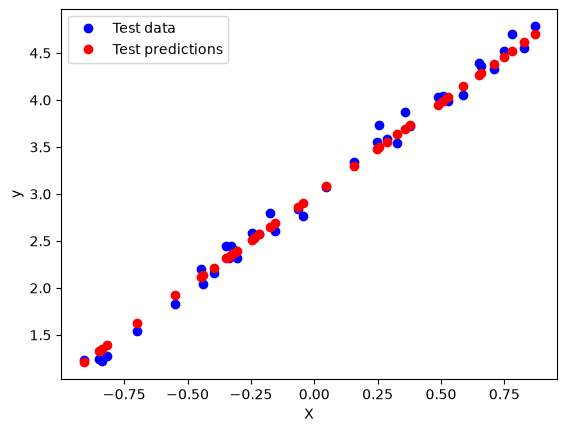

In [25]:
y_test_pred_custom = model.forward(X_test)

plt.plot(X_test, y_test, 'bo', label='Test data')
plt.plot(X_test, y_test_pred_custom.T, 'ro', label='Test predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

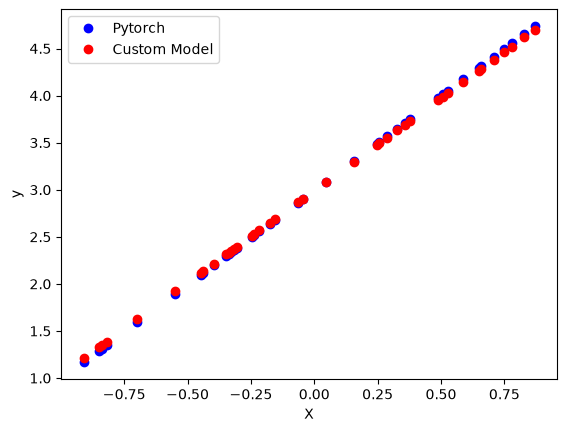

In [26]:
plt.plot(X_test, y_test_pred, 'bo', label='Pytorch')
plt.plot(X_test, y_test_pred_custom.T, 'ro', label='Custom Model')
plt.xlabel('X') 
plt.ylabel('y')
plt.legend()